# `dataset_builder` — Per-point Pipeline Demo

This notebook walks through exactly what `dataset_builder.py` does for a **single chosen sampling point**, step by step.  There are no CLI arguments and no full-dataset runs — just the core logic exposed cell by cell.

### Pipeline (per point)

```
CSV  →  pick one row
             │
             ▼
   1. Validate & filter NaN coordinates
             │
             ▼
   2. Build Shapely Point(lon, lat)
             │
             ▼
   3. _delineate_catchment_core(point, dem, flow_acc_threshold)
             │
             ├──► Polygon  — watershed boundary
             ├──► Point    — snapped pour point on stream network
             └──► float    — flow accumulation at pour point
             │
             ▼
   4. Assemble result row → GeoDataFrame
             │
             ▼
   5. _save_checkpoint  →  GeoPackage
             │
             ▼
   6. Visualise on Folium map
```

> **Change the sample** by editing `CHOSEN_NOTATION` in the *Configuration* cell below and re-running.

## 0 — Imports

In [1]:
from __future__ import annotations

import math
import sys
import tempfile
import time
import traceback
import warnings
from pathlib import Path

import branca.colormap as cm
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon

warnings.filterwarnings("ignore")

# Make the repo root importable (notebook lives in notebooks/)
try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from eoflow.catchment import _delineate_catchment_core
from scripts.dataset_builder import (
    _load_checkpoint,
    _save_checkpoint,
)

print("Imports OK")
print("Repo root:", REPO_ROOT)

Imports OK
Repo root: /home/finley/Work/RDS/projects/enforce/repos/eoflow


## 1 — Configuration

**Edit `CHOSEN_NOTATION` to switch sample.**  Available notations are printed after the CSV is loaded.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR  = REPO_ROOT / "data"
CSV_PATH  = DATA_DIR / "devon_water_quality_10.csv"
DEM_PATH  = DATA_DIR / "devon_dem.tif"
DEVON_SHP = DATA_DIR / "devon_county" / "devon_county.shp"

TMPDIR    = Path(tempfile.mkdtemp(prefix="eoflow_db_demo_"))
OUT_GPKG  = TMPDIR / "demo_single_sample.gpkg"

# ── Sample selection ──────────────────────────────────────────────────────
#
# Pick any samplingPoint.notation from the CSV.
# Run the next cell first to see all available notations.
#
CHOSEN_NOTATION = "SW-70620154"   # River Teign at Preston — smallest catchment

# ── Delineation parameter ─────────────────────────────────────────────────
#
# Lower  → denser stream network, smaller snap offset, more headwaters included
# Higher → only major channels; small catchments may fail to snap
#
FLOW_ACC_THRESHOLD = 100

# ── Column names in the CSV ───────────────────────────────────────────────
LAT_COL = "latitude"
LON_COL = "longitude"

for p in [CSV_PATH, DEM_PATH, DEVON_SHP]:
    assert p.exists(), f"Required file not found: {p}"

print(f"CSV         : {CSV_PATH}")
print(f"DEM         : {DEM_PATH}")
print(f"Output GPKG : {OUT_GPKG}")
print(f"Sample      : {CHOSEN_NOTATION}")
print(f"Threshold   : {FLOW_ACC_THRESHOLD} cells")

CSV         : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_water_quality_10.csv
DEM         : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_dem.tif
Output GPKG : /tmp/eoflow_db_demo_1odi9qdv/demo_single_sample.gpkg
Sample      : SW-70620154
Threshold   : 100 cells


## 2 — Load & inspect the CSV

The builder reads the whole CSV first, then works through each unique location. Here we load it and print all available sampling points so you can choose one.

In [3]:
df_all = pd.read_csv(CSV_PATH)
print(f"CSV shape   : {df_all.shape}")
print(f"Columns     : {list(df_all.columns)}")
print()
print("Available samples:")
display(
    df_all[[
        "samplingPoint.notation", "samplingPoint.prefLabel",
        LAT_COL, LON_COL, "result", "unit", "Date"
    ]].style.format({"result": "{:.1f}", LAT_COL: "{:.5f}", LON_COL: "{:.5f}"})
)

CSV shape   : (10, 21)
Columns     : ['id', 'samplingPoint.notation', 'samplingPoint.prefLabel', 'samplingPoint.easting', 'samplingPoint.northing', 'samplingPoint.region', 'samplingPoint.area', 'samplingPoint.subArea', 'samplingPoint.samplingPointStatus', 'samplingPoint.samplingPointType', 'phenomenonTime', 'samplingPurpose', 'sampleMaterialType', 'determinand.notation', 'determinand.prefLabel', 'result', 'unit', 'Date', 'result_numeric', 'longitude', 'latitude']

Available samples:


,samplingPoint.notation,samplingPoint.prefLabel,latitude,longitude,result,unit,Date
0,SW-70420116,RIVER OTTER AT DOTTON MILL,50.68960,-3.29345,57.0,NEPHELOMETRIC TURBIDITY UNITS,2020-01-14
1,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,50.71322,-3.52334,8.6,NEPHELOMETRIC TURBIDITY UNITS,2020-01-22
2,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,50.80452,-3.51123,5.9,NEPHELOMETRIC TURBIDITY UNITS,2020-01-20
3,SW-70620154,RIVER TEIGN AT PRESTON,50.55941,-3.61672,15.0,NEPHELOMETRIC TURBIDITY UNITS,2020-01-09
4,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,50.63192,-3.68312,1.7,NEPHELOMETRIC TURBIDITY UNITS,2020-01-10
5,SW-70720104,RIVER DART AT TOTNES WEIR,50.43855,-3.69044,2.3,NEPHELOMETRIC TURBIDITY UNITS,2020-01-07
6,SW-70826005,RIVER AVON AT HATCH,50.31114,-3.80706,5.0,NEPHELOMETRIC TURBIDITY UNITS,2020-01-02
7,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,50.35090,-3.92408,7.0,NEPHELOMETRIC TURBIDITY UNITS,2020-01-30
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,50.96739,-4.17521,5.8,NEPHELOMETRIC TURBIDITY UNITS,2020-01-24
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,51.01675,-4.02266,6.7,NEPHELOMETRIC TURBIDITY UNITS,2020-01-22


## 3 — Select the chosen row

The builder drops rows with missing coordinates before doing anything else (`build_dataset` step 1). We mirror that here, then isolate the single row for `CHOSEN_NOTATION`.

In [4]:
# Step 1 of build_dataset: validate coordinate columns exist
assert LAT_COL in df_all.columns and LON_COL in df_all.columns, (
    f"CSV must contain '{LAT_COL}' and '{LON_COL}' columns. Found: {list(df_all.columns)}"
)
print(f"✓  Coordinate columns '{LAT_COL}' and '{LON_COL}' present")

# Step 1 of build_dataset: drop rows with missing coordinates
valid_mask = df_all[LAT_COL].notna() & df_all[LON_COL].notna()
n_dropped = int((~valid_mask).sum())
df_valid = df_all[valid_mask].copy()
print(f"✓  {len(df_valid)} valid rows retained  ({n_dropped} dropped for missing coords)")

# Isolate our chosen sample
row = df_valid[df_valid["samplingPoint.notation"] == CHOSEN_NOTATION]
assert len(row) > 0, (
    f"Notation '{CHOSEN_NOTATION}' not found.  "
    f"Available: {list(df_valid['samplingPoint.notation'])}"
)
row = row.iloc[0]  # take first if duplicated notation

SITE_NAME = row["samplingPoint.prefLabel"]
LAT       = float(row[LAT_COL])
LON       = float(row[LON_COL])
RESULT    = float(row["result"])
UNIT      = str(row["unit"])
DATE      = str(row["Date"])

print()
print(f"Selected sample")
print(f"  Site name  : {SITE_NAME}")
print(f"  Notation   : {CHOSEN_NOTATION}")
print(f"  Date       : {DATE}")
print(f"  Result     : {RESULT} {UNIT}")
print(f"  Latitude   : {LAT}")
print(f"  Longitude  : {LON}")

✓  Coordinate columns 'latitude' and 'longitude' present
✓  10 valid rows retained  (0 dropped for missing coords)

Selected sample
  Site name  : RIVER TEIGN AT PRESTON
  Notation   : SW-70620154
  Date       : 2020-01-09
  Result     : 15.0 NEPHELOMETRIC TURBIDITY UNITS
  Latitude   : 50.559406974335694
  Longitude  : -3.616723023181938


## 4 — Construct the Shapely Point

Inside `build_dataset` the coordinate pair is turned into a Shapely `Point` with the convention `Point(x=lon, y=lat)` — **longitude first**.  This is what gets passed to `_delineate_catchment_core`.

In [5]:
# Exact line from build_dataset:
#   point = Point(lon, lat)   # shapely Point is (x=lon, y=lat)

sample_point = Point(LON, LAT)

print(f"Point WKT : {sample_point.wkt}")
print(f"  x (lon) : {sample_point.x}")
print(f"  y (lat) : {sample_point.y}")
print()
print("✓  Shapely Point follows (x=lon, y=lat) convention")

Point WKT : POINT (-3.616723023181938 50.559406974335694)
  x (lon) : -3.616723023181938
  y (lat) : 50.559406974335694

✓  Shapely Point follows (x=lon, y=lat) convention


## 5 — Context map: sample location on Devon

Before we run the expensive delineation, we place the sample point on an overview map to confirm the location looks right.

In [6]:
devon_gdf = gpd.read_file(DEVON_SHP).to_crs("EPSG:4326")

ctx_map = folium.Map(
    location=[50.72, -3.80],
    zoom_start=9,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=460,
)

folium.GeoJson(
    devon_gdf.__geo_interface__,
    style_function=lambda _: {
        "fillColor": "#d4e8f0", "color": "#2c6e8a",
        "weight": 2, "fillOpacity": 0.15,
    },
).add_to(ctx_map)

# All other sites — grey
for _, r in df_valid.iterrows():
    is_chosen = r["samplingPoint.notation"] == CHOSEN_NOTATION
    folium.CircleMarker(
        location=[float(r[LAT_COL]), float(r[LON_COL])],
        radius=7 if is_chosen else 5,
        color="#c0392b" if is_chosen else "#7f8c8d",
        fill=True,
        fill_color="#e74c3c" if is_chosen else "#bdc3c7",
        fill_opacity=0.95 if is_chosen else 0.6,
        tooltip=(
            f"{'▶ SELECTED — ' if is_chosen else ''}"
            f"{r['samplingPoint.prefLabel']}  ({r['samplingPoint.notation']})"
        ),
        popup=folium.Popup(
            f"<b>{r['samplingPoint.prefLabel']}</b><br>"
            f"Notation: {r['samplingPoint.notation']}<br>"
            f"Date: {r['Date']}<br>"
            f"Result: {r['result']:.1f} {r['unit']}",
            max_width=230,
        ),
    ).add_to(ctx_map)

ctx_map

## 6 — Catchment delineation

This is the core of each loop iteration inside `build_dataset`.  `_delineate_catchment_core` runs the full pysheds pipeline on the DEM:

1. Load & condition the DEM (fill pits, resolve flats)
2. Compute D8 flow direction
3. Compute flow accumulation grid
4. Snap the pour point to the nearest stream cell (`acc > flow_acc_threshold`)
5. Delineate the upstream contributing area
6. Vectorise → `Polygon`

Returns `(Polygon, snapped_Point, flow_acc_float)`.

> **Takes ~10 s** — the DEM is read and processed in full each time.

In [7]:
print(f"Delineating catchment for '{SITE_NAME}'")
print(f"  Point        : POINT ({LON} {LAT})")
print(f"  DEM          : {DEM_PATH.name}")
print(f"  Threshold    : {FLOW_ACC_THRESHOLD} cells")
print()

t0 = time.perf_counter()

try:
    catchment_polygon, snapped_point, flow_acc = _delineate_catchment_core(
        point=sample_point,
        dem_path=DEM_PATH,
        flow_acc_threshold=FLOW_ACC_THRESHOLD,
    )
    elapsed = time.perf_counter() - t0
    status = "ok"
    error_msg = ""
    print(f"✓  Delineated in {elapsed:.1f}s")

except Exception as exc:
    elapsed = time.perf_counter() - t0
    status = "error"
    error_msg = str(exc)
    catchment_polygon = None
    snapped_point = None
    flow_acc = float("nan")
    print(f"✗  Failed in {elapsed:.1f}s")
    print(f"   Error: {error_msg}")
    traceback.print_exc()

print(f"   Status       : {status}")

Delineating catchment for 'RIVER TEIGN AT PRESTON'
  Point        : POINT (-3.616723023181938 50.559406974335694)
  DEM          : devon_dem.tif
  Threshold    : 100 cells

2026-02-27 15:12:00,320 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.618194, 50.559861)  offset=0.001540°
✓  Delineated in 8.7s
   Status       : ok


## 7 — Inspect the raw results

Print the three return values from `_delineate_catchment_core` and compute some derived statistics.

In [8]:
if status != "ok":
    print("Delineation failed — skipping result inspection.")
else:
    # ── Polygon ──────────────────────────────────────────────────────────
    W, S, E, N = catchment_polygon.bounds
    centroid = catchment_polygon.centroid
    lat_rad = math.radians(centroid.y)
    area_km2 = (
        catchment_polygon.area
        * 111_132.0
        * 111_320.0
        * math.cos(lat_rad)
        / 1e6
    )

    print("Catchment polygon")
    print(f"  Geometry type : {catchment_polygon.geom_type}")
    print(f"  Bounds W,S,E,N: {W:.6f}, {S:.6f}, {E:.6f}, {N:.6f}")
    print(f"  Centroid      : ({centroid.x:.6f}, {centroid.y:.6f})")
    print(f"  Area          : {area_km2:.4f} km²")
    print()

    # ── Snapped pour point ────────────────────────────────────────────────
    dlat_m = (snapped_point.y - LAT) * 111_132.0
    dlon_m = (snapped_point.x - LON) * 111_320.0 * math.cos(lat_rad)
    offset_m = math.sqrt(dlat_m**2 + dlon_m**2)

    print("Snapped pour point")
    print(f"  Original  : ({LON:.6f}, {LAT:.6f})")
    print(f"  Snapped   : ({snapped_point.x:.6f}, {snapped_point.y:.6f})")
    print(f"  Offset    : {offset_m:.1f} m")
    print()

    # ── Flow accumulation ─────────────────────────────────────────────────
    print("Flow accumulation at pour point")
    print(f"  Cells     : {flow_acc:.0f}")
    print(f"  Threshold : {FLOW_ACC_THRESHOLD} cells  (snap criterion)")

Catchment polygon
  Geometry type : Polygon
  Bounds W,S,E,N: -3.618194, 50.558750, -3.613750, 50.562083
  Centroid      : (-3.616160, 50.560297)
  Area          : 0.0619 km²

Snapped pour point
  Original  : (-3.616723, 50.559407)
  Snapped   : (-3.618194, 50.559861)
  Offset    : 115.6 m

Flow accumulation at pour point
  Cells     : 102
  Threshold : 100 cells  (snap criterion)


## 8 — Static plot: catchment, sample point, snapped pour point

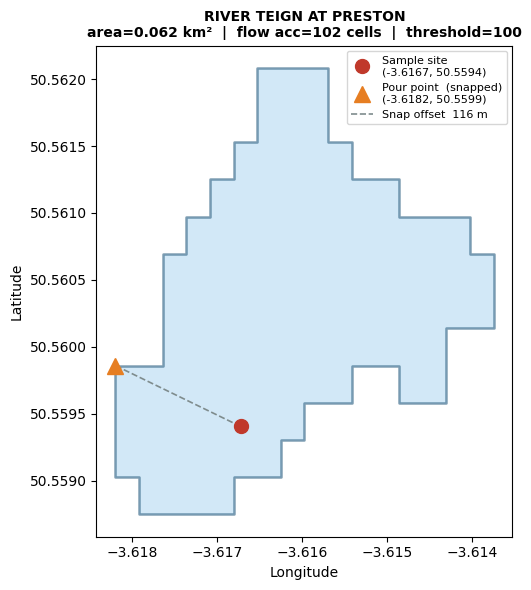

In [9]:
if status != "ok":
    print("Delineation failed — no plot.")
else:
    fig, ax = plt.subplots(figsize=(6, 6))

    poly_gdf = gpd.GeoDataFrame(geometry=[catchment_polygon], crs="EPSG:4326")
    poly_gdf.plot(
        ax=ax,
        facecolor="#aed6f1",
        edgecolor="#1a5276",
        linewidth=1.8,
        alpha=0.55,
        zorder=1,
    )

    # Sample point (original GPS location)
    ax.plot(LON, LAT, "o",
            color="#c0392b", markersize=10, zorder=4,
            label=f"Sample site\n({LON:.4f}, {LAT:.4f})")

    # Snapped pour point
    ax.plot(snapped_point.x, snapped_point.y, "^",
            color="#e67e22", markersize=11, zorder=4,
            label=f"Pour point  (snapped)\n({snapped_point.x:.4f}, {snapped_point.y:.4f})")

    # Snap offset line
    ax.plot(
        [LON, snapped_point.x], [LAT, snapped_point.y],
        "--", color="#7f8c8d", linewidth=1.2, zorder=3,
        label=f"Snap offset  {offset_m:.0f} m",
    )

    ax.set_title(
        f"{SITE_NAME}\n"
        f"area={area_km2:.3f} km²  |  flow acc={flow_acc:.0f} cells  |  threshold={FLOW_ACC_THRESHOLD}",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()

## 9 — Assemble the result row

Inside `build_dataset` the three return values are written back into the running `GeoDataFrame` via `gdf.loc[mask, ...]`.  Here we build the equivalent single-row GeoDataFrame that mirrors exactly what the builder produces.

In [10]:
# Mirror the columns that build_dataset adds to the input CSV row
result_row = row.to_dict()   # all original CSV columns preserved

# Columns added by build_dataset
result_row["delineation_status"] = status
result_row["delineation_error"]  = error_msg
result_row["snap_longitude"]     = snapped_point.x if snapped_point else float("nan")
result_row["snap_latitude"]      = snapped_point.y if snapped_point else float("nan")
result_row["flow_acc_at_pour_point"] = flow_acc
result_row["catchment"]          = catchment_polygon  # the geometry

result_gdf = gpd.GeoDataFrame(
    [result_row],
    geometry="catchment",
    crs="EPSG:4326",
)

print("Result GeoDataFrame")
print(f"  Rows       : {len(result_gdf)}")
print(f"  Columns    : {list(result_gdf.columns)}")
print(f"  CRS        : {result_gdf.crs}")
print(f"  Geom type  : {result_gdf.geometry.geom_type.iloc[0]}")
print()

# Verify the types that tests assert
assert isinstance(result_gdf.iloc[0]["catchment"], Polygon)
assert result_gdf.iloc[0]["delineation_status"] == "ok"
assert result_gdf.iloc[0]["delineation_error"] == ""
assert LAT_COL in result_gdf.columns
assert LON_COL in result_gdf.columns
print("✓  Geometry is a Polygon")
print("✓  delineation_status == 'ok'")
print("✓  Original CSV columns preserved")

Result GeoDataFrame
  Rows       : 1
  Columns    : ['id', 'samplingPoint.notation', 'samplingPoint.prefLabel', 'samplingPoint.easting', 'samplingPoint.northing', 'samplingPoint.region', 'samplingPoint.area', 'samplingPoint.subArea', 'samplingPoint.samplingPointStatus', 'samplingPoint.samplingPointType', 'phenomenonTime', 'samplingPurpose', 'sampleMaterialType', 'determinand.notation', 'determinand.prefLabel', 'result', 'unit', 'Date', 'result_numeric', 'longitude', 'latitude', 'delineation_status', 'delineation_error', 'snap_longitude', 'snap_latitude', 'flow_acc_at_pour_point', 'catchment']
  CRS        : EPSG:4326
  Geom type  : Polygon

✓  Geometry is a Polygon
✓  delineation_status == 'ok'
✓  Original CSV columns preserved


In [18]:
# Styled view of the key output columns
display_cols = [
    "samplingPoint.notation", "samplingPoint.prefLabel",
    "Date", "result", "unit",
    LAT_COL, LON_COL,
    "snap_latitude", "snap_longitude",
    "flow_acc_at_pour_point",
    "delineation_status",
]
result_gdf[[c for c in display_cols if c in result_gdf.columns]].T

,0
samplingPoint.notation,SW-70620154
samplingPoint.prefLabel,RIVER TEIGN AT PRESTON
Date,2020-01-09
result,15.0
unit,NEPHELOMETRIC TURBIDITY UNITS
latitude,50.559407
longitude,-3.616723
snap_latitude,50.559861
snap_longitude,-3.618194
flow_acc_at_pour_point,102.0


## 11 — Folium map: catchment polygon & pour point

The delineated catchment displayed over the base map with the sample site (red circle) and snapped pour point (orange marker) connected by a dashed snap-offset line.

In [19]:
if status != "ok":
    print("Delineation failed — no map.")
else:
    W, S, E, N = catchment_polygon.bounds
    map_centre = [(S + N) / 2, (W + E) / 2]

    catch_map = folium.Map(
        location=map_centre,
        zoom_start=15,
        tiles="CartoDB positron",
        scrollWheelZoom=False,
        width="100%",
        height=500,
    )

    # Catchment polygon
    folium.GeoJson(
        catchment_polygon.__geo_interface__,
        name="Catchment polygon",
        style_function=lambda _: {
            "fillColor": "#aed6f1",
            "color": "#1a5276",
            "weight": 2,
            "fillOpacity": 0.45,
        },
        tooltip=f"{SITE_NAME}  —  {area_km2:.3f} km²",
        popup=folium.Popup(
            f"<b>{SITE_NAME}</b><br>"
            f"Notation : {CHOSEN_NOTATION}<br>"
            f"Area     : {area_km2:.4f} km²<br>"
            f"Bounds   : W={W:.5f}, S={S:.5f}, E={E:.5f}, N={N:.5f}",
            max_width=280,
        ),
    ).add_to(catch_map)

    # Snap offset line
    folium.PolyLine(
        [[LAT, LON], [snapped_point.y, snapped_point.x]],
        color="#7f8c8d", weight=1.8, dash_array="6 4",
        tooltip=f"Snap offset: {offset_m:.1f} m",
    ).add_to(catch_map)

    # Original sample site
    folium.CircleMarker(
        location=[LAT, LON],
        radius=8,
        color="#922b21",
        fill=True, fill_color="#e74c3c", fill_opacity=0.95,
        tooltip=f"Sample site: {SITE_NAME}",
        popup=folium.Popup(
            f"<b>Sample site</b><br>"
            f"{SITE_NAME}<br>"
            f"Date: {DATE}<br>"
            f"Result: {RESULT} {UNIT}<br>"
            f"Coords: ({LON:.5f}, {LAT:.5f})",
            max_width=230,
        ),
    ).add_to(catch_map)

    # Snapped pour point
    folium.Marker(
        location=[snapped_point.y, snapped_point.x],
        icon=folium.Icon(color="orange", icon="tint", prefix="fa"),
        tooltip=(
            f"Snapped pour point<br>"
            f"Flow acc: {flow_acc:.0f} cells<br>"
            f"Offset: {offset_m:.1f} m"
        ),
        popup=folium.Popup(
            f"<b>Snapped pour point</b><br>"
            f"Coords: ({snapped_point.x:.5f}, {snapped_point.y:.5f})<br>"
            f"Flow accumulation: <b>{flow_acc:.0f} cells</b><br>"
            f"Threshold used: {FLOW_ACC_THRESHOLD} cells<br>"
            f"Snap offset: {offset_m:.1f} m",
            max_width=240,
        ),
    ).add_to(catch_map)

    folium.LayerControl(collapsed=False).add_to(catch_map)
    catch_map

## 12 — Devon overview: catchment in regional context

In [20]:
if status != "ok":
    print("Delineation failed — no map.")
else:
    devon_map = folium.Map(
        location=[50.72, -3.80],
        zoom_start=9,
        tiles="CartoDB positron",
        scrollWheelZoom=False,
        width="100%",
        height=480,
    )

    # Devon boundary
    folium.GeoJson(
        devon_gdf.__geo_interface__,
        style_function=lambda _: {
            "fillColor": "#d4e8f0", "color": "#2c6e8a",
            "weight": 2, "fillOpacity": 0.15,
        },
    ).add_to(devon_map)

    # Other sample sites (grey)
    others_fg = folium.FeatureGroup(name="Other sample sites", show=True)
    for _, r in df_valid.iterrows():
        if r["samplingPoint.notation"] == CHOSEN_NOTATION:
            continue
        folium.CircleMarker(
            location=[float(r[LAT_COL]), float(r[LON_COL])],
            radius=5, color="#7f8c8d",
            fill=True, fill_color="#bdc3c7", fill_opacity=0.6,
            tooltip=r["samplingPoint.prefLabel"],
        ).add_to(others_fg)
    others_fg.add_to(devon_map)

    # Delineated catchment
    catch_fg = folium.FeatureGroup(name=f"Catchment — {CHOSEN_NOTATION}", show=True)
    folium.GeoJson(
        catchment_polygon.__geo_interface__,
        style_function=lambda _: {
            "fillColor": "#2980b9", "color": "#1a5276",
            "weight": 2, "fillOpacity": 0.50,
        },
        tooltip=f"{SITE_NAME}  —  {area_km2:.3f} km²",
    ).add_to(catch_fg)
    catch_fg.add_to(devon_map)

    # Selected site marker
    folium.CircleMarker(
        location=[LAT, LON],
        radius=9, color="#922b21",
        fill=True, fill_color="#e74c3c", fill_opacity=0.95,
        tooltip=SITE_NAME,
    ).add_to(devon_map)

    folium.Marker(
        location=[snapped_point.y, snapped_point.x],
        icon=folium.Icon(color="orange", icon="tint", prefix="fa"),
        tooltip=f"Pour point — {flow_acc:.0f} cells",
    ).add_to(devon_map)

    folium.LayerControl(collapsed=False).add_to(devon_map)
    devon_map

## 13 — Effect of `flow_acc_threshold` on snap offset

A lower threshold includes more headwater cells in the stream mask, so the pour point snaps to a stream that is closer to the original GPS location.  The cell below re-runs delineation for a small range of thresholds and compares the snap offsets.

> **Slow** — runs `_delineate_catchment_core` once per threshold value.

In [ ]:
THRESHOLDS = [5, 10, 50, 100, 250, 500]

threshold_results = []

for thresh in THRESHOLDS:
    print(f"  threshold={thresh} … ", end="", flush=True)
    t0 = time.perf_counter()
    try:
        poly_t, snap_t, acc_t = _delineate_catchment_core(
            point=sample_point,
            dem_path=DEM_PATH,
            flow_acc_threshold=thresh,
        )
        elapsed_t = time.perf_counter() - t0
        lat_rad_t = math.radians(poly_t.centroid.y)
        area_t = poly_t.area * 111_132.0 * 111_320.0 * math.cos(lat_rad_t) / 1e6
        dlon = (snap_t.x - LON) * 111_320.0 * math.cos(lat_rad_t)
        dlat = (snap_t.y - LAT) * 111_132.0
        off_t = math.sqrt(dlon**2 + dlat**2)
        threshold_results.append({
            "threshold": thresh,
            "status": "ok",
            "area_km2": area_t,
            "snap_offset_m": off_t,
            "flow_acc": acc_t,
            "elapsed_s": elapsed_t,
        })
        print(f"ok  area={area_t:.3f} km²  offset={off_t:.0f} m  ({elapsed_t:.1f}s)")
    except Exception as exc:
        threshold_results.append({"threshold": thresh, "status": "error",
                                   "area_km2": None, "snap_offset_m": None,
                                   "flow_acc": None, "elapsed_s": time.perf_counter() - t0})
        print(f"FAILED: {exc}")

df_thresh = pd.DataFrame(threshold_results)
print()
display(df_thresh.style.format({
    "area_km2": "{:.4f}", "snap_offset_m": "{:.0f}",
    "flow_acc": "{:.0f}", "elapsed_s": "{:.1f}",
}))

  threshold=5 … 2026-02-27 15:38:53,026 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.616806, 50.559861)  offset=0.000462°
ok  area=0.004 km²  offset=51 m  (10.7s)
  threshold=10 … 

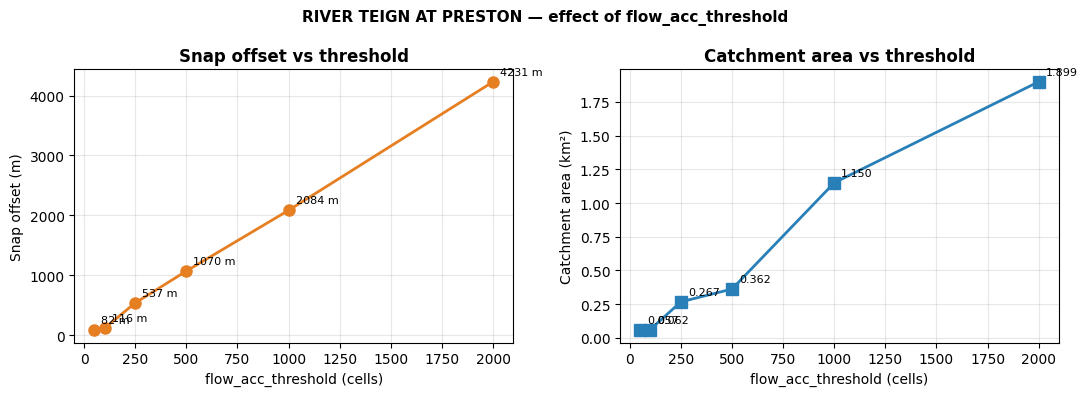

In [ ]:
ok_thresh = df_thresh[df_thresh["status"] == "ok"]

if len(ok_thresh) == 0:
    print("No successful threshold runs to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(ok_thresh["threshold"], ok_thresh["snap_offset_m"],
                 "o-", color="#e67e22", linewidth=2, markersize=8)
    axes[0].set_xlabel("flow_acc_threshold (cells)")
    axes[0].set_ylabel("Snap offset (m)")
    axes[0].set_title("Snap offset vs threshold", fontweight="bold")
    axes[0].grid(True, alpha=0.3)
    for _, r in ok_thresh.iterrows():
        axes[0].annotate(
            f"{r['snap_offset_m']:.0f} m",
            (r["threshold"], r["snap_offset_m"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8,
        )

    axes[1].plot(ok_thresh["threshold"], ok_thresh["area_km2"],
                 "s-", color="#2980b9", linewidth=2, markersize=8)
    axes[1].set_xlabel("flow_acc_threshold (cells)")
    axes[1].set_ylabel("Catchment area (km²)")
    axes[1].set_title("Catchment area vs threshold", fontweight="bold")
    axes[1].grid(True, alpha=0.3)
    for _, r in ok_thresh.iterrows():
        axes[1].annotate(
            f"{r['area_km2']:.3f}",
            (r["threshold"], r["area_km2"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8,
        )

    fig.suptitle(
        f"{SITE_NAME} — effect of flow_acc_threshold",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 14 — Folium map: catchments at different thresholds

Toggle layers in the control to compare how the watershed boundary changes with the threshold.

In [ ]:
if len(ok_thresh) == 0:
    print("No successful threshold runs — no comparison map.")
else:
    LAYER_COLOURS = ["#1abc9c", "#2980b9", "#8e44ad", "#c0392b"]

    # Re-run delineation for each threshold to get the polygon objects
    # (we only stored scalars above; re-use the ones we already computed)
    thresh_polys: dict[int, Polygon] = {}
    thresh_snaps: dict[int, Point]   = {}

    print("Re-collecting polygon objects … ", end="", flush=True)
    for thresh in ok_thresh["threshold"].tolist():
        try:
            p, s, _ = _delineate_catchment_core(
                point=sample_point, dem_path=DEM_PATH,
                flow_acc_threshold=thresh,
            )
            thresh_polys[thresh] = p
            thresh_snaps[thresh] = s
            print(f"{thresh} ", end="", flush=True)
        except Exception:
            pass
    print("done")

    # Bounding box across all polygons for map centring
    all_bounds = [p.bounds for p in thresh_polys.values()]
    map_w = min(b[0] for b in all_bounds)
    map_s = min(b[1] for b in all_bounds)
    map_e = max(b[2] for b in all_bounds)
    map_n = max(b[3] for b in all_bounds)

    cmp_map = folium.Map(
        location=[(map_s + map_n) / 2, (map_w + map_e) / 2],
        zoom_start=15,
        tiles="CartoDB positron",
        scrollWheelZoom=False,
        width="100%",
        height=520,
    )

    for i, (thresh, poly) in enumerate(thresh_polys.items()):
        col = LAYER_COLOURS[i % len(LAYER_COLOURS)]
        row_t = ok_thresh[ok_thresh["threshold"] == thresh].iloc[0]

        layer = folium.FeatureGroup(
            name=f"threshold={thresh}  ({row_t['area_km2']:.3f} km², offset={row_t['snap_offset_m']:.0f} m)",
            show=(thresh == FLOW_ACC_THRESHOLD),
        )
        folium.GeoJson(
            poly.__geo_interface__,
            style_function=lambda _, c=col: {
                "fillColor": c, "color": c,
                "weight": 2, "fillOpacity": 0.25,
            },
            tooltip=f"threshold={thresh}  area={row_t['area_km2']:.3f} km²",
        ).add_to(layer)

        snap = thresh_snaps[thresh]
        folium.CircleMarker(
            location=[snap.y, snap.x],
            radius=6, color=col,
            fill=True, fill_color=col, fill_opacity=0.9,
            tooltip=f"Pour point (thresh={thresh}), offset={row_t['snap_offset_m']:.0f} m",
        ).add_to(layer)
        layer.add_to(cmp_map)

    # Sample site always visible
    folium.CircleMarker(
        location=[LAT, LON],
        radius=9, color="#2c3e50",
        fill=True, fill_color="#e74c3c", fill_opacity=0.95,
        tooltip=f"Sample site: {SITE_NAME}",
    ).add_to(cmp_map)

    folium.LayerControl(collapsed=False).add_to(cmp_map)
    cmp_map

Re-collecting polygon objects … 2026-02-27 15:34:23,793 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.617639, 50.559861)  offset=0.001022°
50 2026-02-27 15:34:33,034 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.618194, 50.559861)  offset=0.001540°
100 2026-02-27 15:34:42,870 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.610972, 50.556250)  offset=0.006560°
250 2026-02-27 15:34:51,613 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.602639, 50.562917)  offset=0.014515°
500 2026-02-27 15:34:59,865 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.599861, 50.544028)  offset=0.022822°
1000 2026-02-27 15:35:07,776 - eoflow.catchment - INFO -   Pour point snapped: (-3.616723, 50.559407) → (-3.567083, 50.580694)  offset=0.054012°
2000 done


In [ ]:
cmp_map

## Summary

The table below shows every step of the pipeline that `dataset_builder.py` runs for a single `(lat, lon)` pair, with the corresponding function and the value produced for the chosen sample.

In [16]:
summary_data = [
    ("Load CSV",              "pd.read_csv",                CSV_PATH.name),
    ("Validate columns",     "build_dataset (internal)",   f"'{LAT_COL}' and '{LON_COL}' present ✓"),
    ("Filter NaN coords",    "build_dataset (internal)",   f"0 rows dropped from {len(df_all)}"),
    ("Select row",           "DataFrame lookup",           f"{CHOSEN_NOTATION}  —  {SITE_NAME}"),
    ("Construct Point",      "shapely.geometry.Point",     f"POINT ({LON} {LAT})"),
    ("Delineate",            "_delineate_catchment_core",  status),
    ("Catchment polygon",    "returns Polygon",
     f"{area_km2:.4f} km²  bounds=({W:.4f},{S:.4f},{E:.4f},{N:.4f})" if status=="ok" else "N/A"),
    ("Snapped pour point",   "returns Point",
     f"({snapped_point.x:.5f}, {snapped_point.y:.5f})  offset={offset_m:.0f} m" if status=="ok" else "N/A"),
    ("Flow accumulation",    "returns float",
     f"{flow_acc:.0f} cells  (threshold={FLOW_ACC_THRESHOLD})" if status=="ok" else "N/A"),
    ("delineation_status",   "added column",               status),
    ("delineation_error",    "added column",               error_msg if error_msg else "(empty)"),
    ("snap_longitude",       "added column",
     f"{snapped_point.x:.6f}" if status=="ok" else "NaN"),
    ("snap_latitude",        "added column",
     f"{snapped_point.y:.6f}" if status=="ok" else "NaN"),
    ("flow_acc_at_pour_point","added column",
     f"{flow_acc:.0f}" if status=="ok" else "NaN"),
    ("Save checkpoint",      "_save_checkpoint",           f"{OUT_GPKG.name}  ({OUT_GPKG.stat().st_size/1024:.1f} kB)"),
    ("Reload checkpoint",    "_load_checkpoint",           f"{len(loaded)} row(s) — round-trip OK"),
]

df_summary = pd.DataFrame(summary_data, columns=["Step", "Function / source", "Value"])
df_summary.style.set_properties(**{"text-align": "left"}).hide(axis="index")

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/eoflow_db_demo_1odi9qdv/demo_single_sample.gpkg'